Distribución de etiquetas - positivos, negativos, prevalencia %, ratio neg/pos, weight

In [2]:
import pandas as pd

RUTA = r'C:\Users\trodr\Documents\proyecto-torax-v2.0\01-dataset\dataset-completo-merge\df_subset_2994_valido.csv'

LABELS = ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
          'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity',
          'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia', 'Pneumothorax']

def tabla_distribucion(df, labels=LABELS, factor=0.75):
    df = df.copy()
    df[labels] = df[labels].replace(-1, 0).fillna(0)   # U-zeros
    n = len(df)
    filas = []
    for lab in labels:
        pos = int(df[lab].sum())
        neg = n - pos
        ratio = neg / pos if pos else float('nan')
        filas.append({
            'Etiqueta': lab,
            'Positivos': pos,
            'Negativos': neg,
            'Prevalencia (%)': round(100 * pos / n, 2),
            'Ratio neg/pos': round(ratio, 2),
            'pos_weight (x0.75)': round(ratio * factor, 2),
        })
    return (pd.DataFrame(filas)
              .sort_values('Positivos', ascending=False)
              .reset_index(drop=True))

df = pd.read_csv(RUTA)
tabla_5_1 = tabla_distribucion(df)
print(f'N = {len(df)} imágenes')
tabla_5_1

N = 2994 imágenes


,Etiqueta,Positivos,Negativos,Prevalencia (%),Ratio neg/pos,pos_weight (x0.75)
0,No Finding,991,2003,33.10,2.02,1.52
1,Pleural Effusion,704,2290,23.51,3.25,2.44
2,Lung Opacity,663,2331,22.14,3.52,2.64
3,Atelectasis,602,2392,20.11,3.97,2.98
4,Cardiomegaly,582,2412,19.44,4.14,3.11
5,Edema,378,2616,12.63,6.92,5.19
6,Pneumonia,220,2774,7.35,12.61,9.46
7,Consolidation,141,2853,4.71,20.23,15.18
8,Pneumothorax,136,2858,4.54,21.01,15.76
9,Enlarged Cardiomediastinum,100,2894,3.34,28.94,21.71


Prevalencia y desbalance del dataset

In [3]:
def tabla_resumen_desbalance(t, umbral=5.0):
    grupos = {
        f'Frecuentes (prevalencia ≥ {umbral:.0f}%)': t[t['Prevalencia (%)'] >= umbral],
        f'Cola rara (prevalencia < {umbral:.0f}%)':  t[t['Prevalencia (%)'] <  umbral],
    }
    total_pos = t['Positivos'].sum()
    filas = []
    for nombre, g in grupos.items():
        filas.append({
            'Grupo': nombre,
            'N° de etiquetas': len(g),
            'Positivos (total)': int(g['Positivos'].sum()),
            '% del total de positivos': round(100 * g['Positivos'].sum() / total_pos, 2),
            'Prevalencia mín–máx (%)': f"{g['Prevalencia (%)'].min():.2f} – {g['Prevalencia (%)'].max():.2f}",
            'Prevalencia media (%)': round(g['Prevalencia (%)'].mean(), 2),
            'Ratio neg/pos mín–máx': f"{g['Ratio neg/pos'].min():.2f} – {g['Ratio neg/pos'].max():.2f}",
            'pos_weight mín–máx': f"{g['pos_weight (x0.75)'].min():.2f} – {g['pos_weight (x0.75)'].max():.2f}",
        })
    return pd.DataFrame(filas)

tabla_5_2 = tabla_resumen_desbalance(tabla_5_1)
print(f"Anotaciones positivas totales: {tabla_5_1['Positivos'].sum()}")
tabla_5_2

Anotaciones positivas totales: 4664


,Grupo,N° de etiquetas,Positivos (total),% del total de positivos,Prevalencia mín–máx (%),Prevalencia media (%),Ratio neg/pos mín–máx,pos_weight mín–máx
0,Frecuentes (prevalencia ≥ 5%),7,4140,88.77,7.35 – 33.10,19.75,2.02 – 12.61,1.52 – 9.46
1,Cola rara (prevalencia < 5%),6,524,11.23,0.57 – 4.71,2.92,20.23 – 175.12,15.18 – 131.34


Histograma de prevalencias

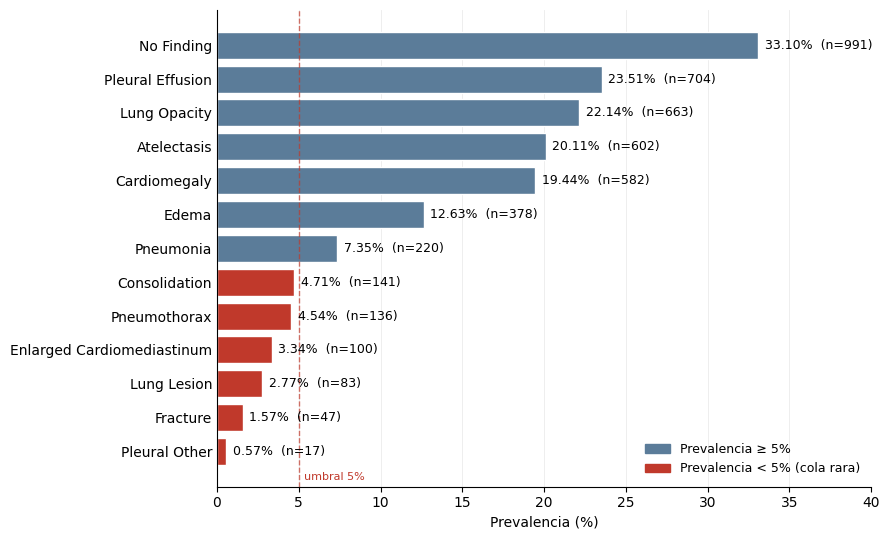

'C:\\Users\\trodr\\Documents\\proyecto-torax-v2.0\\figura_5_1_prevalencias.png'

In [4]:
import matplotlib.pyplot as plt

RUTA_FIG = r'C:\Users\trodr\Documents\proyecto-torax-v2.0\figura_5_1_prevalencias.png'

def figura_prevalencias(t, umbral=5.0, ruta=RUTA_FIG):
    t = t.sort_values('Prevalencia (%)', ascending=True)   # ascendente: la mayor queda arriba
    colores = ['#C0392B' if p < umbral else '#5B7C99' for p in t['Prevalencia (%)']]

    fig, ax = plt.subplots(figsize=(9, 5.5))
    barras = ax.barh(t['Etiqueta'], t['Prevalencia (%)'], color=colores, edgecolor='white')

    for barra, pos, prev in zip(barras, t['Positivos'], t['Prevalencia (%)']):
        ax.text(prev + 0.4, barra.get_y() + barra.get_height()/2,
                f'{prev:.2f}%  (n={pos})', va='center', fontsize=9)

    ax.axvline(umbral, color='#C0392B', linestyle='--', linewidth=1, alpha=0.7)
    ax.text(umbral + 0.3, -0.85, f'umbral {umbral:.0f}%', color='#C0392B', fontsize=8)

    ax.set_xlabel('Prevalencia (%)')
    ax.set_xlim(0, 40)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='y', length=0)
    ax.grid(axis='x', alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)

    manijas = [plt.Rectangle((0,0),1,1, color='#5B7C99'),
               plt.Rectangle((0,0),1,1, color='#C0392B')]
    ax.legend(manijas, [f'Prevalencia ≥ {umbral:.0f}%', f'Prevalencia < {umbral:.0f}% (cola rara)'],
              loc='lower right', frameon=False, fontsize=9)

    plt.tight_layout()
    plt.savefig(ruta, dpi=300, bbox_inches='tight')
    plt.show()
    return ruta

figura_prevalencias(tabla_5_1)

Imagenes por Finding

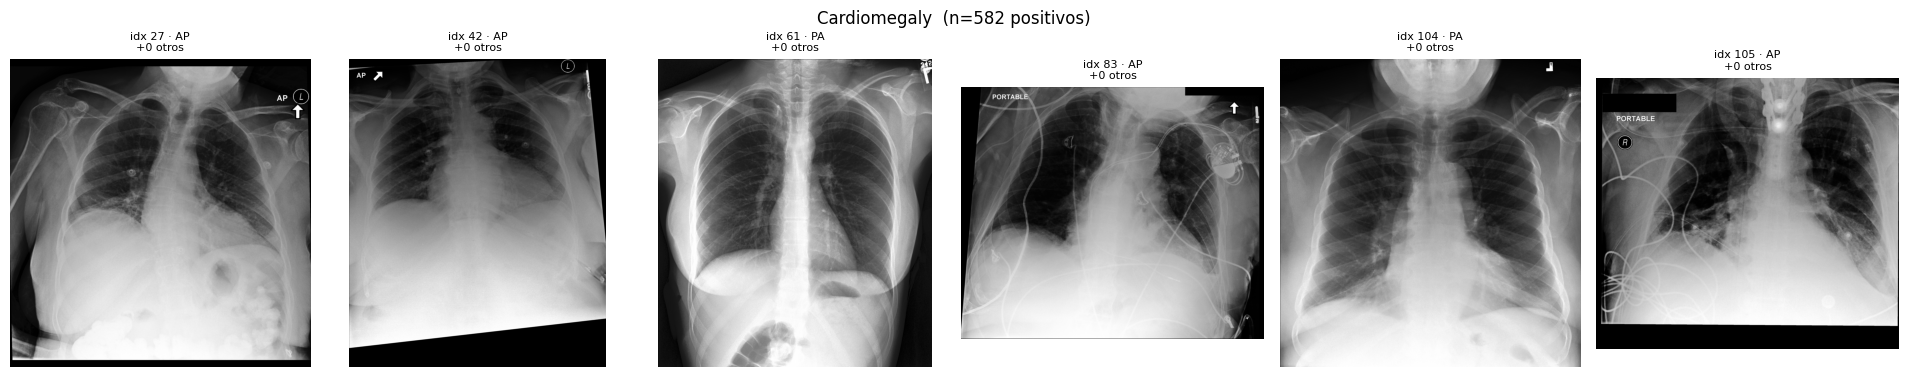

,full_path,ViewPosition,n_otros
27,files/p10/p10178472/s59799535/c26783b5-87fe699...,AP,0.0
42,files/p13/p13395021/s59056691/9f7c83a0-eb7c247...,AP,0.0
61,files/p13/p13528093/s54313364/4b378bbd-0e9e238...,PA,0.0
83,files/p13/p13636434/s58807677/46729949-44e8155...,AP,0.0
104,files/p16/p16477367/s57986868/242d0bd1-72fa39d...,PA,0.0
105,files/p10/p10699336/s54995304/a5ee43c2-cc2123e...,AP,0.0


In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

BASE_IMG = r'C:\Users\trodr\Documents\proyecto-torax-v2.0\01-dataset\dataset-completo-merge\3000imagenes'
RUTA_CSV = r'C:\Users\trodr\Documents\proyecto-torax-v2.0\01-dataset\dataset-completo-merge\df_subset_2994_valido.csv'

LABELS = ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
          'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity',
          'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia', 'Pneumothorax']

df = pd.read_csv(RUTA_CSV)
df[LABELS] = df[LABELS].replace(-1, 0).fillna(0)

def abrir(fila):
    return Image.open(os.path.join(BASE_IMG, fila['full_path'].replace('/', os.sep))).convert('L')

def revisar(df, label, n=6):
    """Muestra los casos más 'puros': positivos en `label` con menos hallazgos concurrentes."""
    otros = [l for l in LABELS if l not in (label, 'No Finding')]
    d = df[df[label] == 1].copy()
    d['n_otros'] = d[otros].sum(axis=1)
    c = d.nsmallest(n, 'n_otros')

    fig, axes = plt.subplots(1, len(c), figsize=(3.2 * len(c), 3.8))
    axes = [axes] if len(c) == 1 else axes
    for ax, (idx, fila) in zip(axes, c.iterrows()):
        ax.imshow(abrir(fila), cmap='gray')
        ax.set_title(f"idx {idx} · {fila['ViewPosition']}\n+{int(fila['n_otros'])} otros", fontsize=8)
        ax.axis('off')
    fig.suptitle(f'{label}  (n={int(df[label].sum())} positivos)', fontsize=12)
    plt.tight_layout(); plt.show()
    return c[['full_path', 'ViewPosition', 'n_otros']]

revisar(df, 'Cardiomegaly')

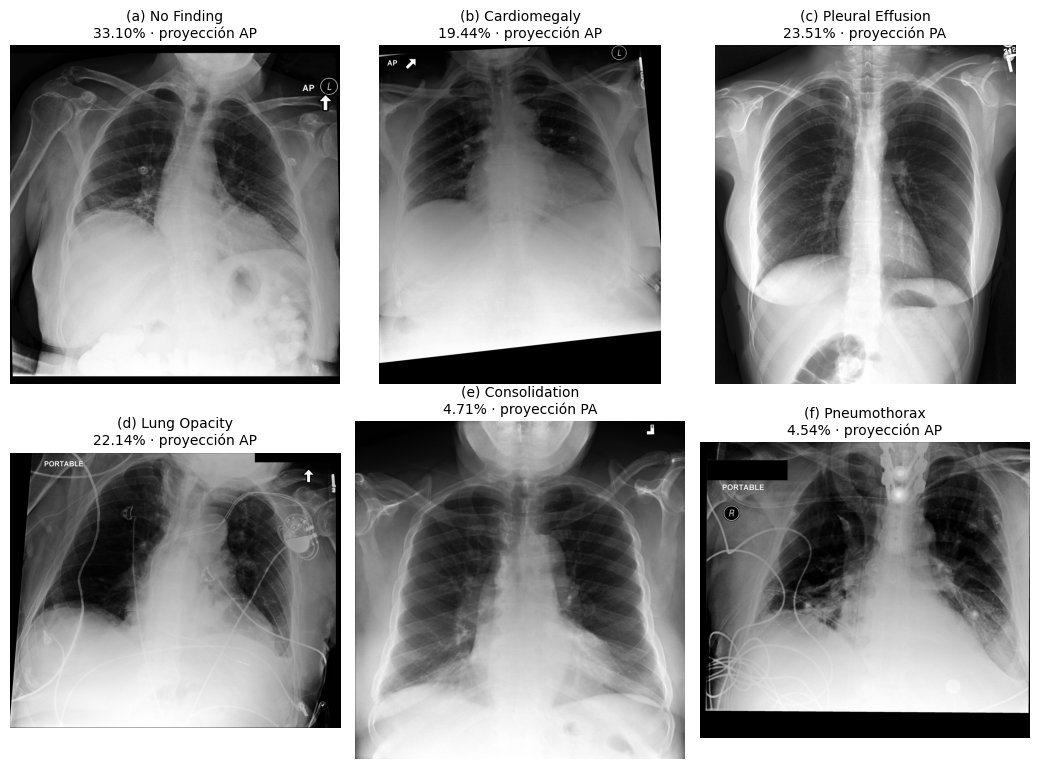

In [7]:
SELECCION = {          # reemplaza por los índices que elegiste
    'No Finding': 27,
    'Cardiomegaly': 42,
    'Pleural Effusion': 61,
    'Lung Opacity': 83,
    'Consolidation': 104,
    'Pneumothorax': 105,
}
def a_cuadrado(img, fondo=0):
    """Acolcha la imagen a cuadrado con borde negro, sin deformar la anatomía."""
    lado = max(img.size)
    lienzo = Image.new('L', (lado, lado), fondo)
    lienzo.paste(img, ((lado - img.size[0]) // 2, (lado - img.size[1]) // 2))
    return lienzo
def panel_hallazgos(df, seleccion, tabla,
                    ruta_out=os.path.join(BASE_IMG, '..', 'figura_5_2_hallazgos.png')):
    fig, axes = plt.subplots(2, 3, figsize=(10.5, 7.8))
    for ax, letra, (label, idx) in zip(axes.ravel(), 'abcdef', seleccion.items()):
        fila = df.loc[idx]
        prev = tabla.loc[tabla['Etiqueta'] == label, 'Prevalencia (%)'].iloc[0]
        ax.imshow(abrir(fila), cmap='gray')
        ax.set_title(f'({letra}) {label}\n{prev:.2f}% · proyección {fila["ViewPosition"]}', fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(ruta_out, dpi=300, bbox_inches='tight')
    plt.show()

panel_hallazgos(df, SELECCION, tabla_5_1)

Co-ocurrencia de etiquetas o findings

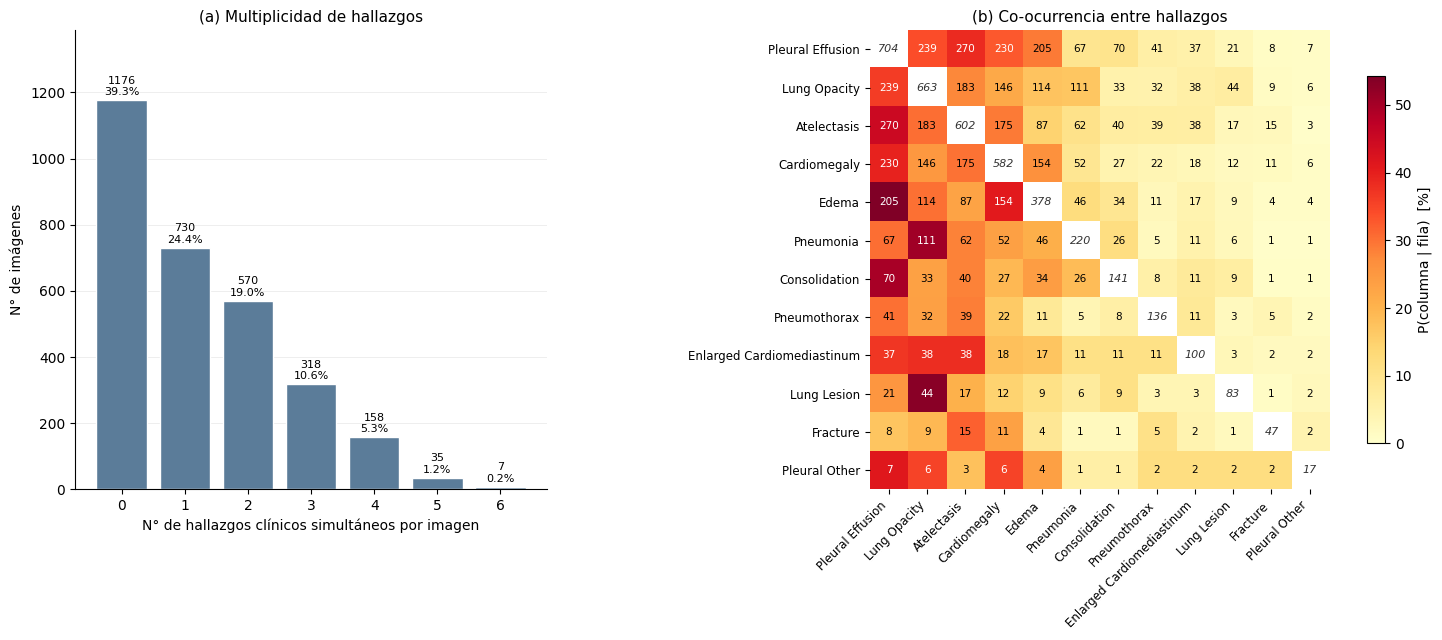

,Hallazgo A,Hallazgo B,Co-ocurrencias,P(B|A) %
0,Pleural Effusion,Atelectasis,270,38.4
1,Pleural Effusion,Lung Opacity,239,33.9
2,Pleural Effusion,Cardiomegaly,230,32.7
3,Pleural Effusion,Edema,205,29.1
4,Lung Opacity,Atelectasis,183,27.6
5,Atelectasis,Cardiomegaly,175,29.1
6,Cardiomegaly,Edema,154,26.5
7,Lung Opacity,Cardiomegaly,146,22.0
8,Lung Opacity,Edema,114,17.2
9,Lung Opacity,Pneumonia,111,16.7


In [8]:
import numpy as np

CLINICOS = [l for l in LABELS if l != 'No Finding']   # 12 labels; No Finding es excluyente por definición

def figura_coocurrencia(df, ruta_out=r'C:\Users\trodr\Documents\proyecto-torax-v2.0\figura_5_3_coocurrencia.png'):
    M = df[CLINICOS].values
    conteo = M.T @ M                                   # diagonal = positivos totales
    diag = np.diag(conteo).astype(float)
    cond = 100 * conteo / diag[:, None]                # P(columna | fila) en %
    np.fill_diagonal(cond, np.nan)                     # la diagonal no aporta color

    orden = np.argsort(-diag)
    etq = [CLINICOS[i] for i in orden]
    conteo, cond = conteo[np.ix_(orden, orden)], cond[np.ix_(orden, orden)]

    n_hall = df[CLINICOS].sum(axis=1).astype(int).value_counts().sort_index()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5),
                                   gridspec_kw={'width_ratios': [1, 1.6]})

    # (a) hallazgos por imagen
    barras = ax1.bar(n_hall.index, n_hall.values, color='#5B7C99', edgecolor='white')
    for b, v in zip(barras, n_hall.values):
        ax1.text(b.get_x() + b.get_width()/2, v + 15, f'{v}\n{100*v/len(df):.1f}%',
                 ha='center', fontsize=8)
    ax1.set_xlabel('N° de hallazgos clínicos simultáneos por imagen')
    ax1.set_ylabel('N° de imágenes')
    ax1.set_title('(a) Multiplicidad de hallazgos', fontsize=11)
    ax1.set_ylim(0, n_hall.max() * 1.18)
    ax1.spines[['top', 'right']].set_visible(False)
    ax1.set_axisbelow(True); ax1.grid(axis='y', alpha=0.25, linewidth=0.6)

    # (b) heatmap condicional
    im = ax2.imshow(cond, cmap='YlOrRd', vmin=0, vmax=np.nanmax(cond))
    for i in range(len(etq)):
        for j in range(len(etq)):
            if i == j:
                ax2.text(j, i, f'{int(conteo[i, i])}', ha='center', va='center',
                         fontsize=8, color='#333', style='italic')
            else:
                c = 'white' if cond[i, j] > 0.6 * np.nanmax(cond) else 'black'
                ax2.text(j, i, f'{int(conteo[i, j])}', ha='center', va='center', fontsize=7.5, color=c)
    ax2.set_xticks(range(len(etq))); ax2.set_xticklabels(etq, rotation=45, ha='right', fontsize=8.5)
    ax2.set_yticks(range(len(etq))); ax2.set_yticklabels(etq, fontsize=8.5)
    ax2.set_title('(b) Co-ocurrencia entre hallazgos', fontsize=11)
    for spine in ax2.spines.values():
        spine.set_visible(False)
    fig.colorbar(im, ax=ax2, shrink=0.8, label='P(columna | fila)  [%]')

    plt.tight_layout()
    plt.savefig(ruta_out, dpi=300, bbox_inches='tight')
    plt.show()

    # pares más frecuentes, para citar en el texto
    pares = [(etq[i], etq[j], int(conteo[i, j]), cond[i, j])
             for i in range(len(etq)) for j in range(i+1, len(etq))]
    top = pd.DataFrame(sorted(pares, key=lambda x: -x[2])[:10],
                       columns=['Hallazgo A', 'Hallazgo B', 'Co-ocurrencias', 'P(B|A) %'])
    return top.round(1)

figura_coocurrencia(df)

dimensioens imagenes

In [9]:
CACHE_DIM = r'C:\Users\trodr\Documents\proyecto-torax-v2.0\dimensiones_2994.csv'

def cargar_dimensiones(df, cache=CACHE_DIM):
    if os.path.exists(cache):
        return pd.read_csv(cache)
    filas = []
    for k, (_, fila) in enumerate(df.iterrows(), 1):
        ruta = os.path.join(BASE_IMG, fila['full_path'].replace('/', os.sep))
        with Image.open(ruta) as img:          # solo lee la cabecera, no decodifica
            w, h = img.size
        filas.append({'dicom_id': fila['dicom_id'], 'ViewPosition': fila['ViewPosition'],
                      'ancho': w, 'alto': h})
        if k % 500 == 0:
            print(f'{k}/{len(df)}')
    d = pd.DataFrame(filas)
    d.to_csv(cache, index=False)
    return d

dim = cargar_dimensiones(df)
dim['aspecto'] = dim['alto'] / dim['ancho']
dim['megapixeles'] = dim['ancho'] * dim['alto'] / 1e6

resumen_dim = dim[['ancho', 'alto', 'aspecto', 'megapixeles']].describe().T[
    ['min', '25%', '50%', '75%', 'max', 'mean', 'std']].round(2)
print(resumen_dim)

500/2994
1000/2994
1500/2994
2000/2994
2500/2994
                 min      25%      50%      75%      max     mean     std
ancho        1469.00  2539.00  2544.00  3050.00  3056.00  2607.11  372.85
alto         1605.00  2539.00  2774.00  3056.00  3056.00  2716.89  376.73
aspecto         0.69     0.83     1.16     1.20     1.49     1.06    0.17
megapixeles     2.36     7.58     7.77     7.77     7.77     7.12    1.39


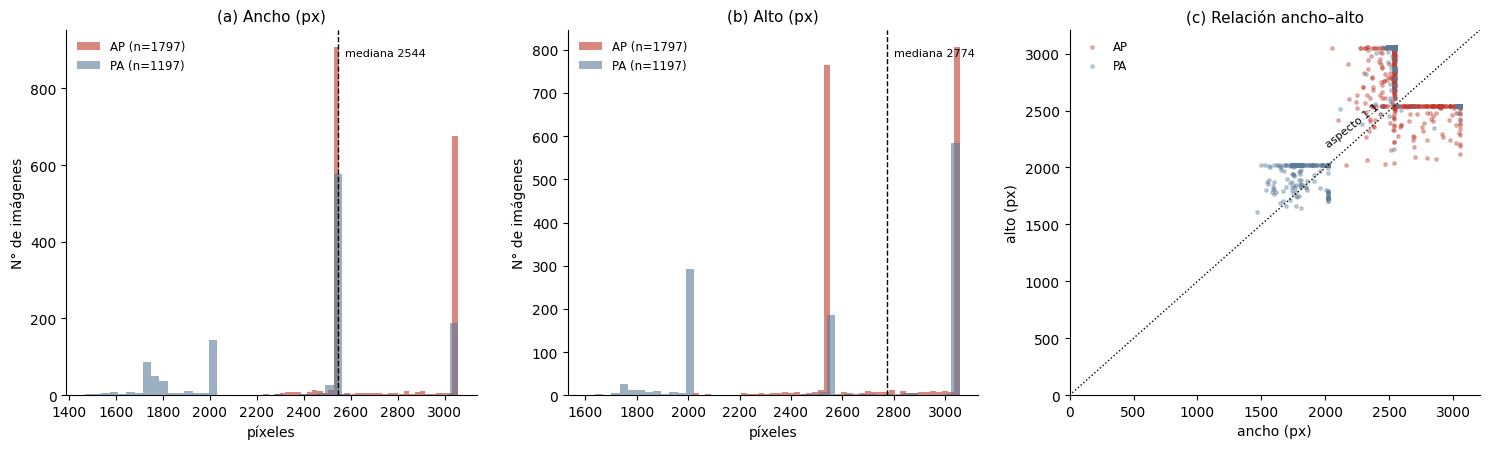

In [10]:
def figura_dimensiones(dim, ruta_out=r'C:\Users\trodr\Documents\proyecto-torax-v2.0\figura_5_4_dimensiones.png'):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
    colores = {'AP': '#C0392B', 'PA': '#5B7C99'}

    for ax, col, titulo in zip(axes[:2], ['ancho', 'alto'],
                               ['(a) Ancho (px)', '(b) Alto (px)']):
        for vp, g in dim.groupby('ViewPosition'):
            ax.hist(g[col], bins=45, alpha=0.6, label=f'{vp} (n={len(g)})', color=colores[vp])
        ax.axvline(dim[col].median(), color='black', linestyle='--', linewidth=1)
        ax.text(dim[col].median(), ax.get_ylim()[1]*0.95, f'  mediana {dim[col].median():.0f}',
                fontsize=8, va='top')
        ax.set_xlabel('píxeles'); ax.set_ylabel('N° de imágenes')
        ax.set_title(titulo, fontsize=11)
        ax.legend(frameon=False, fontsize=8.5)
        ax.spines[['top', 'right']].set_visible(False)

    ax = axes[2]
    for vp, g in dim.groupby('ViewPosition'):
        ax.scatter(g['ancho'], g['alto'], s=6, alpha=0.35, color=colores[vp], label=vp)
    lim = [0, max(dim['ancho'].max(), dim['alto'].max()) * 1.05]
    ax.plot(lim, lim, color='black', linestyle=':', linewidth=1)
    ax.text(lim[1]*0.62, lim[1]*0.68, 'aspecto 1:1', fontsize=8, rotation=38)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('ancho (px)'); ax.set_ylabel('alto (px)')
    ax.set_title('(c) Relación ancho–alto', fontsize=11)
    ax.legend(frameon=False, fontsize=8.5)
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(ruta_out, dpi=300, bbox_inches='tight')
    plt.show()

figura_dimensiones(dim)

In [11]:
dim['orientación'] = np.where(dim['alto'] > dim['ancho'], 'Vertical',
                     np.where(dim['alto'] < dim['ancho'], 'Horizontal', 'Cuadrada'))

formatos = (dim.groupby(['ancho', 'alto', 'orientación'])
              .size().reset_index(name='N')
              .sort_values('N', ascending=False))
formatos['%'] = (100 * formatos['N'] / len(dim)).round(2)
formatos['formato'] = formatos['ancho'].astype(str) + ' × ' + formatos['alto'].astype(str)

print(f"Formatos distintos: {len(formatos)}")
print(f"Cobertura del top 10: {formatos['%'].head(10).sum():.1f}%\n")
print(formatos[['formato', 'orientación', 'N', '%']].head(12).to_string(index=False))
print('\nPor orientación:')
print(dim['orientación'].value_counts().to_frame('N').assign(
      pct=lambda x: (100*x['N']/len(dim)).round(2)))
print('\nOrientación × proyección:')
print(pd.crosstab(dim['ViewPosition'], dim['orientación'], margins=True))

Formatos distintos: 550
Cobertura del top 10: 78.3%

    formato orientación    N     %
2544 × 3056    Vertical 1135 37.91
3056 × 2544  Horizontal  619 20.67
3050 × 2539  Horizontal  205  6.85
2539 × 3050    Vertical  175  5.85
1736 × 2022    Vertical   72  2.40
2021 × 2021    Cuadrada   56  1.87
2022 × 2022    Cuadrada   53  1.77
2022 × 1736  Horizontal   20  0.67
2516 × 3056    Vertical    5  0.17
2544 × 3052    Vertical    5  0.17
2524 × 3056    Vertical    4  0.13
1771 × 2021    Vertical    4  0.13

Por orientación:
                N    pct
orientación             
Vertical     1818  60.72
Horizontal   1064  35.54
Cuadrada      112   3.74

Orientación × proyección:
orientación   Cuadrada  Horizontal  Vertical   All
ViewPosition                                      
AP                   4         822       971  1797
PA                 108         242       847  1197
All                112        1064      1818  2994


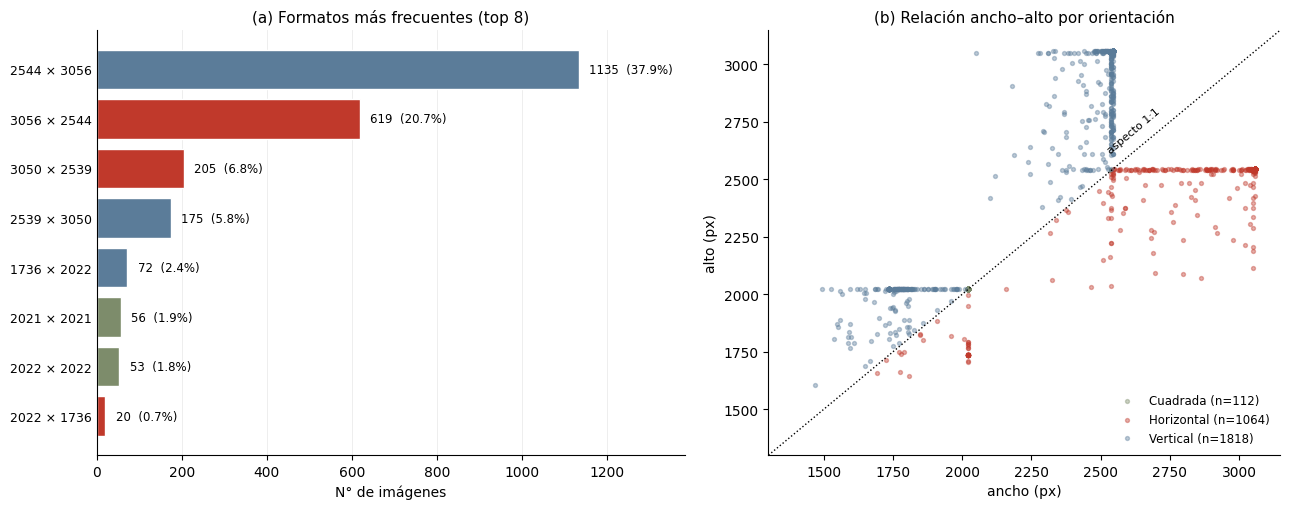

In [12]:
def figura_dimensiones_v2(dim, formatos, top=8,
                          ruta_out=r'C:\Users\trodr\Documents\proyecto-torax-v2.0\figura_5_4_dimensiones.png'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.2),
                                   gridspec_kw={'width_ratios': [1.15, 1]})
    c_or = {'Vertical': '#5B7C99', 'Horizontal': '#C0392B', 'Cuadrada': '#7D8C6B'}

    f = formatos.head(top).iloc[::-1]
    ax1.barh(f['formato'], f['N'], color=[c_or[o] for o in f['orientación']], edgecolor='white')
    for y, (n, p) in enumerate(zip(f['N'], f['%'])):
        ax1.text(n + len(dim)*0.008, y, f'{n}  ({p:.1f}%)', va='center', fontsize=8.5)
    ax1.set_xlabel('N° de imágenes')
    ax1.set_title(f'(a) Formatos más frecuentes (top {top})', fontsize=11)
    ax1.set_xlim(0, f['N'].max() * 1.22)
    ax1.tick_params(axis='y', length=0, labelsize=9)
    ax1.spines[['top', 'right']].set_visible(False)
    ax1.set_axisbelow(True); ax1.grid(axis='x', alpha=0.25, linewidth=0.6)

    for o, g in dim.groupby('orientación'):
        ax2.scatter(g['ancho'], g['alto'], s=8, alpha=0.4, color=c_or[o],
                    label=f'{o} (n={len(g)})')
    lim = [1300, max(dim['ancho'].max(), dim['alto'].max()) * 1.03]
    ax2.plot(lim, lim, color='black', linestyle=':', linewidth=1)
    ax2.text(lim[1]*0.80, lim[1]*0.83, 'aspecto 1:1', fontsize=8, rotation=40)
    ax2.set_xlim(lim); ax2.set_ylim(lim)
    ax2.set_xlabel('ancho (px)'); ax2.set_ylabel('alto (px)')
    ax2.set_title('(b) Relación ancho–alto por orientación', fontsize=11)
    ax2.legend(frameon=False, fontsize=8.5, loc='lower right')
    ax2.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(ruta_out, dpi=300, bbox_inches='tight')
    plt.show()

figura_dimensiones_v2(dim, formatos)

In [17]:
import os
import pandas as pd
from PIL import Image

RUTA_CACHE = r'C:\Users\trodr\Documents\proyecto-torax-v2.0\dimensiones_subset.csv'

def extraer_dimensiones(df, col_ruta='full_path', ruta_cache=RUTA_CACHE):
    if os.path.exists(ruta_cache):
        print(f'Caché encontrada: {ruta_cache}')
        return pd.read_csv(ruta_cache)

    filas, errores = [], []
    for i, (dicom, ruta, vp) in enumerate(
            zip(df['dicom_id'], df[col_ruta], df['ViewPosition']), 1):
        try:
            with Image.open(ruta) as im:
                ancho, alto = im.size
            filas.append((dicom, vp, int(ancho), int(alto)))
        except Exception as e:
            errores.append((dicom, str(e)))
        if i % 500 == 0:
            print(f'  {i}/{len(df)}  ok={len(filas)}  err={len(errores)}')

    print(f'\nLeídas: {len(filas)} | Fallidas: {len(errores)}')
    if errores[:3]:
        for d, e in errores[:3]:
            print(f'  ! {d}: {e}')
    if not filas:
        raise RuntimeError('Ninguna imagen se pudo abrir. Revisa col_ruta y los paths.')

    dim = pd.DataFrame(filas, columns=['dicom_id', 'ViewPosition', 'ancho', 'alto'])
    dim['ancho'] = pd.to_numeric(dim['ancho'])
    dim['alto']  = pd.to_numeric(dim['alto'])
    dim['aspecto']   = (dim['ancho'] / dim['alto']).round(3)
    dim['megapixel'] = (dim['ancho'] * dim['alto'] / 1e6).round(2)
    dim['orientacion'] = pd.cut(
        dim['ancho'] - dim['alto'], bins=[-float('inf'), -1, 0, float('inf')],
        labels=['Vertical', 'Cuadrada', 'Horizontal'])

    dim.to_csv(ruta_cache, index=False)
    print(f'Guardado: {ruta_cache}  ({len(dim)} filas)')
    return dim

dim = extraer_dimensiones(df)

  500/2994  ok=0  err=500
  1000/2994  ok=0  err=1000
  1500/2994  ok=0  err=1500
  2000/2994  ok=0  err=2000
  2500/2994  ok=0  err=2500

Leídas: 0 | Fallidas: 2994
  ! 51adabdf-4234d20c-a63f7056-421c65ab-6dabfa41: [Errno 2] No such file or directory: 'files/p16/p16700191/s51325054/51adabdf-4234d20c-a63f7056-421c65ab-6dabfa41.jpg'
  ! 89177690-364bac2f-5d496304-387f233c-db26c1fd: [Errno 2] No such file or directory: 'files/p18/p18452091/s58217747/89177690-364bac2f-5d496304-387f233c-db26c1fd.jpg'
  ! 3b14f064-390ac420-34a6ad8c-351114dd-66126ab3: [Errno 2] No such file or directory: 'files/p13/p13742148/s58404524/3b14f064-390ac420-34a6ad8c-351114dd-66126ab3.jpg'


RuntimeError: Ninguna imagen se pudo abrir. Revisa col_ruta y los paths.

In [21]:
import os
import pandas as pd
from PIL import Image

BASE = r'C:\Users\trodr\Documents\proyecto-torax-v2.0\01-dataset\dataset-completo-merge\3000imagenes'
RUTA_CACHE = r'C:\Users\trodr\Documents\proyecto-torax-v2.0\dimensiones_subset.csv'

def extraer_dimensiones(df, base=BASE, ruta_cache=RUTA_CACHE):
    if os.path.exists(ruta_cache):
        print(f'Caché encontrada: {ruta_cache}')
        return pd.read_csv(ruta_cache)

    filas, errores = [], []
    for i, (dicom, rel, vp) in enumerate(
            zip(df['dicom_id'], df['full_path'], df['ViewPosition']), 1):
        ruta = os.path.join(base, str(rel).replace('/', os.sep))
        try:
            with Image.open(ruta) as im:
                ancho, alto = im.size
            filas.append((dicom, vp, int(ancho), int(alto)))
        except Exception as e:
            errores.append((dicom, str(e)))
        if i % 500 == 0:
            print(f'  {i}/{len(df)}  ok={len(filas)}  err={len(errores)}')

    print(f'\nLeídas: {len(filas)} | Fallidas: {len(errores)}')
    for d, e in errores[:3]:
        print(f'  ! {d}: {e}')
    if not filas:
        raise RuntimeError('Ninguna imagen se pudo abrir. Revisa BASE.')

    dim = pd.DataFrame(filas, columns=['dicom_id', 'ViewPosition', 'ancho', 'alto'])
    dim['aspecto']   = (dim['ancho'] / dim['alto']).round(3)
    dim['megapixel'] = (dim['ancho'] * dim['alto'] / 1e6).round(2)
    dim['orientacion'] = pd.cut(
        dim['ancho'] - dim['alto'], bins=[-float('inf'), -1, 0, float('inf')],
        labels=['Vertical', 'Cuadrada', 'Horizontal'])

    dim.to_csv(ruta_cache, index=False)
    print(f'Guardado: {ruta_cache}  ({len(dim)} filas)')
    return dim

dim = extraer_dimensiones(df)

  500/2994  ok=500  err=0
  1000/2994  ok=1000  err=0
  1500/2994  ok=1500  err=0
  2000/2994  ok=2000  err=0
  2500/2994  ok=2500  err=0

Leídas: 2994 | Fallidas: 0
Guardado: C:\Users\trodr\Documents\proyecto-torax-v2.0\dimensiones_subset.csv  (2994 filas)


In [22]:
# Tabla 3 — estadísticos de dimensiones
t = dim[['ancho', 'alto', 'aspecto', 'megapixel']].describe(percentiles=[.25, .5, .75]).T
print(t[['min', '25%', '50%', '75%', 'max', 'mean', 'std']].round(2))

# Tabla 4 — orientación × proyección
print(pd.crosstab(dim['orientacion'], dim['ViewPosition'],
                  margins=True, margins_name='Total'))

# Contexto para las notas al pie
print('\nFormatos únicos:', len(dim.groupby(['ancho', 'alto'])))
print(dim.groupby(['ancho', 'alto']).size().sort_values(ascending=False).head(6))

               min      25%      50%      75%      max     mean     std
ancho      1469.00  2539.00  2544.00  3050.00  3056.00  2607.11  372.85
alto       1605.00  2539.00  2774.00  3056.00  3056.00  2716.89  376.73
aspecto       0.67     0.83     0.86     1.20     1.44     0.97    0.17
megapixel     2.36     7.58     7.77     7.77     7.77     7.12    1.38
ViewPosition    AP    PA  Total
orientacion                    
Vertical       971   847   1818
Cuadrada         4   108    112
Horizontal     822   242   1064
Total         1797  1197   2994

Formatos únicos: 550
ancho  alto
2544   3056    1135
3056   2544     619
3050   2539     205
2539   3050     175
1736   2022      72
2021   2021      56
dtype: int64
